<h2 style="text-align:center;"> HELLENIC OPEN UNIVERSITY - SCHOOL OF SCIENCE AND TECHNOLOGY</h2>
<h2 style="text-align:center;"> DATA SCIENCE AND MACHINE LEARNING : DAMA61 ACAD. YEAR 2025-26</h2>

<h3 style="text-align:center;"> WRITTEN ASSIGNMENT 4 - Solutions</h3>

### Helpful configurations

In [1]:
# increase the width of the notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# Problem 1

In this problem, you will build and evaluate a baseline Multilayer Perceptron (MLP) for image classification using the CIFAR-10 dataset. The objective is to familiarize yourself with the end-to-end workflow of
data preprocessing, model construction, training, and evaluation, while gaining insight into the limitations
of simple fully connected networks when applied to image data.</br>
<i>Note: Use 42 as the random seed value wherever possible and accuracy as a metric for training the MLPs.</i>

1) Load the CIFAR-10 dataset using Keras, normalize all pixel values to the range [0,1], then shuffle
and split the full dataset (60,000 images) into three subsets: 60% training, 20% validation, and 20% test.
Print the shapes of all three splits. [10%]

2) Build a baseline MLP classifier using Keras with the following structure:</br>
    • A Flatten layer to convert each 2D image into a 1D vector</br>
    • Two hidden Dense layers containing 20 and 10 units, respectively, with ReLU activation</br>
    • An output Dense layer with 10 units and softmax activation</br>

After building the model, compile it using the SparseCategoricalCrossentropy loss function, the SGD optimizer, and add accuracy to the metrics.</br>
Finally, print the model summary to verify that the architecture is correct. [30%]

3) Train your baseline MLP model using the training and validation sets you created earlier. Allow the model to train for 40 epochs with a batch size equal to 64. After training, plot the training versus the validation loss and the training versus the validation accuracy. Finally, write a short comment discussing whether the model appears to be underfitting, overfitting, or learning appropriately for a simple MLP on CIFAR-10. [30%]

4) Evaluate the baseline model by computing its loss and accuracy on the test set. Compare the test accuracy with the validation accuracy you observed during training. Are they similar, or is there a large gap? What does this tell you about the model’s ability to generalize? Briefly comment on the overall performance of this simple MLP on CIFAR-10. [20%]

5) Modify the previous MLP model by keeping the same structure, but increasing the number of units in the hidden layers to 100 and 50, respectively. Compile and re-train the new model using the same settings. Plot the training versus the validation loss and the training versus the validation accuracy for the new model. Compare and briefly discuss the outcomes relative to the baseline model. [10%]

### Question 1

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

print("Original training set shape:", x_train_full.shape, y_train_full.shape)
print("Original test set shape:    ", x_test.shape, y_test.shape)

# Normalize the pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

Original training set shape: (50000, 32, 32, 3) (50000, 1)
Original test set shape:     (10000, 32, 32, 3) (10000, 1)


In [3]:
# Combine train and test to split as 60/20/20
X = np.concatenate([x_train_full, x_test], axis=0)
Y = np.concatenate([y_train_full, y_test], axis=0)

# Flatten labels to 1D
Y = Y.reshape(-1)

print("Full dataset:", X.shape, Y.shape)  # should be (60000, 32, 32, 3)

np.random.seed(42)  # for reproducibility

Full dataset: (60000, 32, 32, 3) (60000,)


In [4]:
# Shuffle the full dataset (for a proper random split)
indices = np.random.permutation(len(X))
X = X[indices]
Y = Y[indices]

# Split the full dateset to: 60% / 20% / 20%
n_total = len(X)  # 60000
n_train = int(0.6 * n_total)  # 36000
n_valid_and_test = int(0.2 * n_total)  # 12000

X_train = X[:n_train]
y_train = Y[:n_train]

X_valid = X[n_train:n_train + n_valid_and_test]
y_valid = Y[n_train:n_train + n_valid_and_test]

X_test = X[n_train + n_valid_and_test:]
y_test = Y[n_train + n_valid_and_test:]

# 6. Print shapes to verify
print("Training set:   ", X_train.shape, y_train.shape)
print("Validation set: ", X_valid.shape, y_valid.shape)
print("Test set:       ", X_test.shape, y_test.shape)

Training set:    (36000, 32, 32, 3) (36000,)
Validation set:  (12000, 32, 32, 3) (12000,)
Test set:        (12000, 32, 32, 3) (12000,)


### Question 2

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

model = Sequential([Input(shape=(32, 32, 3)),
                    Flatten(),
                    Dense(20, activation="relu"),
                    Dense(10, activation="relu"),
                    Dense(10, activation="softmax")
                   ])

model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │        61,460 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,780 (241.33 KB)

 Trainable params: 61,780 (241.33 KB)

 Non-trainable params: 0 (0.00 B)

### Question 3

In [6]:
# Train model
history = model.fit(X_train, y_train,
                    epochs=40,
                    batch_size=64,
                    validation_data=(X_valid, y_valid)
                   )

Epoch 1/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 902us/step - accuracy: 0.1529 - loss: 2.2684 - val_accuracy: 0.2313 - val_loss: 2.1081
Epoch 2/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - accuracy: 0.2550 - loss: 2.0488 - val_accuracy: 0.2772 - val_loss: 2.0026
Epoch 3/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 747us/step - accuracy: 0.3127 - loss: 1.9157 - val_accuracy: 0.3320 - val_loss: 1.8747
Epoch 4/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.3371 - loss: 1.8461 - val_accuracy: 0.3491 - val_loss: 1.8084
Epoch 5/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - accuracy: 0.3484 - loss: 1.7981 - val_accuracy: 0.3564 - val_loss: 1.8019
Epoch 6/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step - accuracy: 0.3579 - loss: 1.7840 - val_accuracy: 0.3548 - val_loss: 1.7911
Epoch 7/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 734us/step - accuracy: 0.3691 - loss: 1.7641 - val_accuracy: 0.3597 - val_loss: 1.7870
Epoch 8/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step - accuracy: 0.3794 - loss: 1.7387 - 

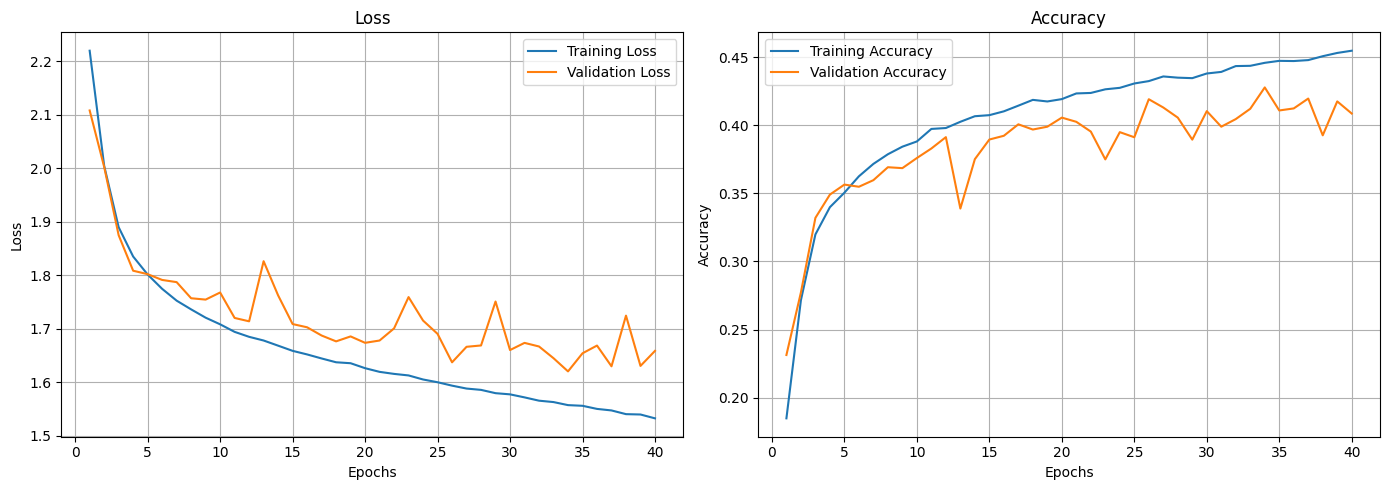

In [7]:
import matplotlib.pyplot as plt

# Extract the training history
epochs_range = np.array(history.epoch) + 1
loss = history.history["loss"]
val_loss = history.history["val_loss"]

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

# Create 1×2 subplot grid
plt.figure(figsize=(14, 5))

# ---- Loss subplot ----
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ---- Accuracy subplot ----
plt.subplot(1, 2, 2)
plt.plot(epochs_range, accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

It is evident that after epoch 15 the model started overfitting the data since the training loss is going down while the validation loss stagnates. This can be also derived from the Accuracy figure, where validation accuracy after epoch 15 does not improve significantly.

### Question 4

In [8]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss:     1.6571
Test accuracy: 0.4051


The results are similar (almost exact) to that of the validation set. The model behaves poorly and cannot generalize very well.

### Question 5

In [9]:
# Define the MLP model
model_wider = Sequential([Input(shape=(32, 32, 3)),
                          Flatten(),
                          Dense(100, activation="relu"),  # increased units
                          Dense(50, activation="relu"),  # increased units
                          Dense(10, activation="softmax")
                         ])

# Compile
model_wider.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])

model_wider.summary()

# Train the model
history_wider = model_wider.fit(X_train, y_train,
                                epochs=40,              # same number of epochs as before
                                batch_size=64,
                                validation_data=(X_valid, y_valid)
                               )

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,860 (1.19 MB)

 Trainable params: 312,860 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2182 - loss: 2.1279 - val_accuracy: 0.3327 - val_loss: 1.8990
Epoch 2/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3329 - loss: 1.8727 - val_accuracy: 0.3659 - val_loss: 1.7976
Epoch 3/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3734 - loss: 1.7824 - val_accuracy: 0.3499 - val_loss: 1.8360
Epoch 4/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.3931 - loss: 1.7162 - val_accuracy: 0.4071 - val_loss: 1.7089
Epoch 5/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4108 - loss: 1.6804 - val_accuracy: 0.4050 - val_loss: 1.6950
Epoch 6/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4250 - loss: 1.6366 - val_accuracy: 0.4160 - val_loss: 1.6389
Epoch 7/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4292 - loss: 1.6197 - val_accuracy: 0.4265 - val_loss: 1.6241
Epoch 8/40
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4381 - loss: 1.5869 - val_accuracy: 0.

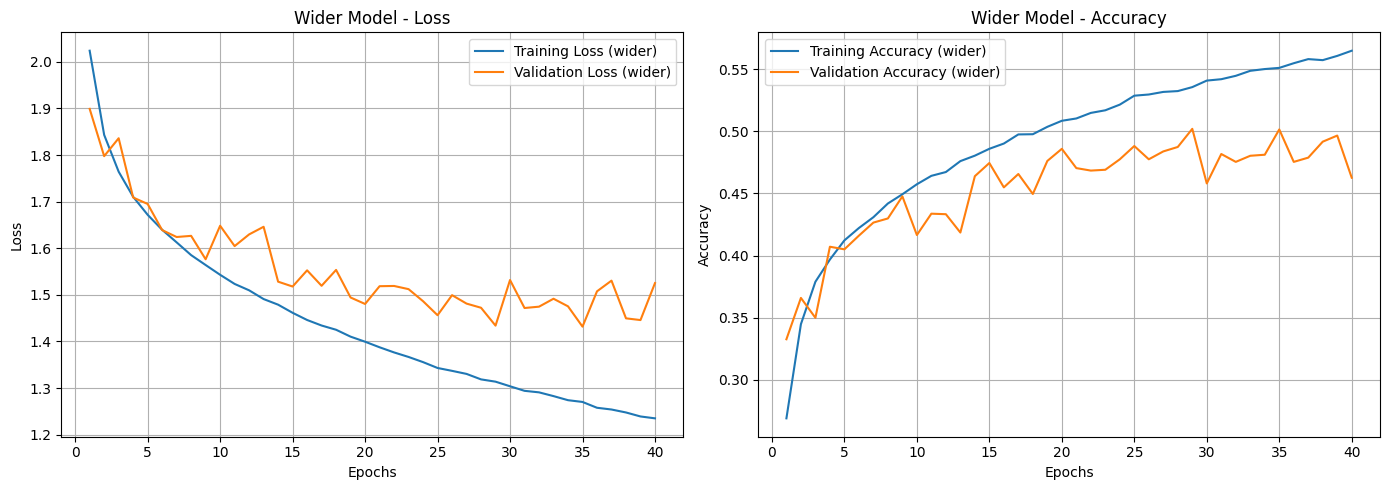

Wider model - Test loss:     1.5137
Wider model - Test accuracy: 0.4587


In [10]:
# Plot the learning curves (loss + accuracy) for the wider model
epochs_axis = np.array(history_wider.epoch) + 1

loss_w = history_wider.history["loss"]
val_loss_w = history_wider.history["val_loss"]

acc_w = history_wider.history["accuracy"]
val_acc_w = history_wider.history["val_accuracy"]

plt.figure(figsize=(14, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs_axis, loss_w, label = "Training Loss (wider)")
plt.plot(epochs_axis, val_loss_w, label = "Validation Loss (wider)")
plt.title("Wider Model - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs_axis, acc_w, label="Training Accuracy (wider)")
plt.plot(epochs_axis, val_acc_w, label="Validation Accuracy (wider)")
plt.title("Wider Model - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# (Optional) Evaluate on the test set for comparison
test_loss_w, test_accuracy_w = model_wider.evaluate(X_test, y_test, verbose=0)
print(f"Wider model - Test loss:     {test_loss_w:.4f}")
print(f"Wider model - Test accuracy: {test_accuracy_w:.4f}")

There is a slight improvement in accuracy for both validation and test sets. However, the model starts overfitting quite early during trianing, i.e. after the 10th epoch. This is evident since the training loss and training accuracy improve significantly while the same metrics for validation improve slightly.

# Problem 2
This problem focuses on improving the training behavior and performance of the baseline MLP model developed in Problem 1. Through systematic experimentation with weight initialization, optimizers, regularization techniques, and learning rate scheduling, you will explore how architectural and training choices influence convergence, generalization, and overall model robustness.<br>
<i>Note: Use 42 as the random seed value wherever possible, accuracy as a metric for training the MLPs and 20 epochs and a batch size of 32 for all models.</i>

1) Recreate the MLP from Problem 1 and train the model using two different initializations: A He Normal and a Glorot Uniform. Choose the initialization that performs better using the Adam optimizer with learning rate 0.001. Using the best initialization, train the model again with two optimizers, an SGD with learing rate equal to 0.001 and momentum equal to 0, as well as an Adam with learning rate 0.001. Plot the learning curves of each experiment. [25%]

2) Starting from the best model configuration identified in the previous step, add Batch Normalization after each hidden layer and 30% Dropout after at least one hidden layer. Train the model and plot its loss and accuracy. [25%]

3) Starting from the model configuration of the previous step, apply a learning rate scheduling strategy that reduces the learning rate by 0.1 every 10 epochs during training. Train the model with the learning rate scheduler enabled and plot its loss and accuracy over epochs. [25%]

4) Based on all experiments in this problem, write a brief comment reflecting on the overall process. You may consider how initialization and optimizer choice affected training, the impact of Batch Normalization and Dropout, and what you learned about improving neural network training compared to the baseline model. [25%]

### Preprocess the data

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

print("Original training set shape:", x_train_full.shape, y_train_full.shape)
print("Original test set shape:    ", x_test.shape, y_test.shape)

# Normalize the pixel values to [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Combine the train and test to split as 60/20/20
X = np.concatenate([x_train_full, x_test], axis=0)
Y = np.concatenate([y_train_full, y_test], axis=0)

# Flatten labels to 1D
Y = Y.reshape(-1)

print("Full dataset:", X.shape, Y.shape)  # should be (60000, 32, 32, 3)

np.random.seed(42)  # for reproducibility

# Shuffle the full dataset (for a proper random split)
indices = np.random.permutation(len(X))
X = X[indices]
Y = Y[indices]

# Split the data to: 60% / 20% / 20%
n_total = len(X)  # 60000
n_train = int(0.6 * n_total)  # 36000
n_valid_and_test = int(0.2 * n_total)  # 12000

X_train = X[:n_train]
y_train = Y[:n_train]

X_valid = X[n_train:n_train + n_valid_and_test]
y_valid = Y[n_train:n_train + n_valid_and_test]

X_test = X[n_train + n_valid_and_test:]
y_test = Y[n_train + n_valid_and_test:]

# Print shapes to verify
print(f"Training set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_valid.shape}, {y_valid.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Original training set shape: (50000, 32, 32, 3) (50000, 1)
Original test set shape:     (10000, 32, 32, 3) (10000, 1)
Full dataset: (60000, 32, 32, 3) (60000,)
Training set: (36000, 32, 32, 3), (36000,)
Validation set: (12000, 32, 32, 3), (12000,)
Test set: (12000, 32, 32, 3), (12000,)


### Question 1

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense

# set the seed numbers for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# Build a model with a given weights initializer
def build_mlp(initializer):
    model = Sequential([Input(shape=(32, 32, 3)),
                        Flatten(),
                        Dense(100, activation="relu", kernel_initializer=initializer),
                        Dense(50, activation="relu", kernel_initializer=initializer),
                        Dense(10, activation="softmax")]
                      )
    return model

In [13]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(history, title_prefix):
    epochs_range = np.array(history.epoch) + 1
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]

    plt.figure(figsize=(12, 4))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} — Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} — Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [14]:
# Compare He vs Glorot (same optimizer: Adam)
from tensorflow.keras.optimizers import Adam

EPOCHS = 20
BATCH_SIZE = 32

# Model with He initialization
model_he = build_mlp("he_normal")

model_he.compile(loss = "sparse_categorical_crossentropy", 
                 optimizer = Adam(learning_rate=1e-3),
                 metrics = ["accuracy"]
                )

history_he = model_he.fit(X_train, y_train,
                          epochs = EPOCHS,
                          batch_size = BATCH_SIZE,
                          validation_data = (X_valid, y_valid),
                          verbose = 1
                         )

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2427 - loss: 2.0521 - val_accuracy: 0.3503 - val_loss: 1.8402
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3516 - loss: 1.7848 - val_accuracy: 0.3833 - val_loss: 1.7367
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3857 - loss: 1.6989 - val_accuracy: 0.4058 - val_loss: 1.6662
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4064 - loss: 1.6547 - val_accuracy: 0.4045 - val_loss: 1.6593
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4196 - loss: 1.6282 - val_accuracy: 0.4135 - val_loss: 1.6365
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4249 - loss: 1.6038 - val_accuracy: 0.4088 - val_loss: 1.6479
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4339 - loss: 1.5800 - val_accuracy: 0.4193 - val_loss: 1.6237
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4395 - loss: 1.5639 - 

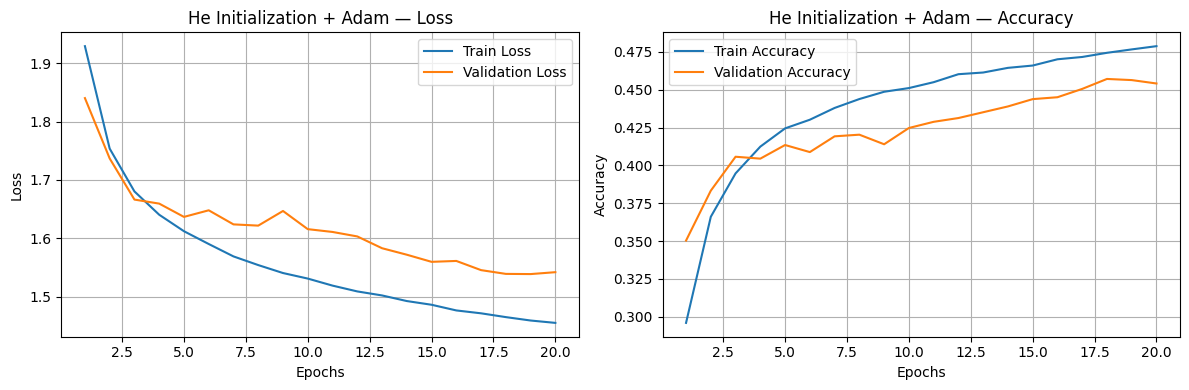

In [15]:
plot_loss_accuracy(history_he, "He Initialization + Adam")

In [16]:
# Model with Glorot initialization
model_glorot = build_mlp("glorot_uniform")

model_glorot.compile(loss = "sparse_categorical_crossentropy",
                     optimizer = Adam(learning_rate=1e-3),
                     metrics = ["accuracy"]
                    )

history_glorot = model_glorot.fit(X_train, y_train,
                                  epochs=EPOCHS,
                                  batch_size=BATCH_SIZE,
                                  validation_data=(X_valid, y_valid),
                                  verbose=1
                                 )

val_acc_he = history_he.history["val_accuracy"][-1]
val_acc_glorot = history_glorot.history["val_accuracy"][-1]

print(f"He Normal  + Adam  -> final val accuracy: {val_acc_he:.4f}")
print(f"Glorot    + Adam  -> final val accuracy: {val_acc_glorot:.4f}")

# Choose the best initialization
best_init = "he_normal" if val_acc_he >= val_acc_glorot else "glorot_uniform"
print(f"\nBest initialization based on validation accuracy: {best_init}\n")

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2506 - loss: 2.0397 - val_accuracy: 0.3424 - val_loss: 1.8643
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3549 - loss: 1.7877 - val_accuracy: 0.3661 - val_loss: 1.7718
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3942 - loss: 1.6960 - val_accuracy: 0.3984 - val_loss: 1.6924
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4124 - loss: 1.6454 - val_accuracy: 0.4065 - val_loss: 1.6766
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4284 - loss: 1.6030 - val_accuracy: 0.4191 - val_loss: 1.6299
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4361 - loss: 1.5715 - val_accuracy: 0.4263 - val_loss: 1.6073
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4446 - loss: 1.5476 - val_accuracy: 0.4388 - val_loss: 1.5815
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4524 - loss: 1.5283 - 

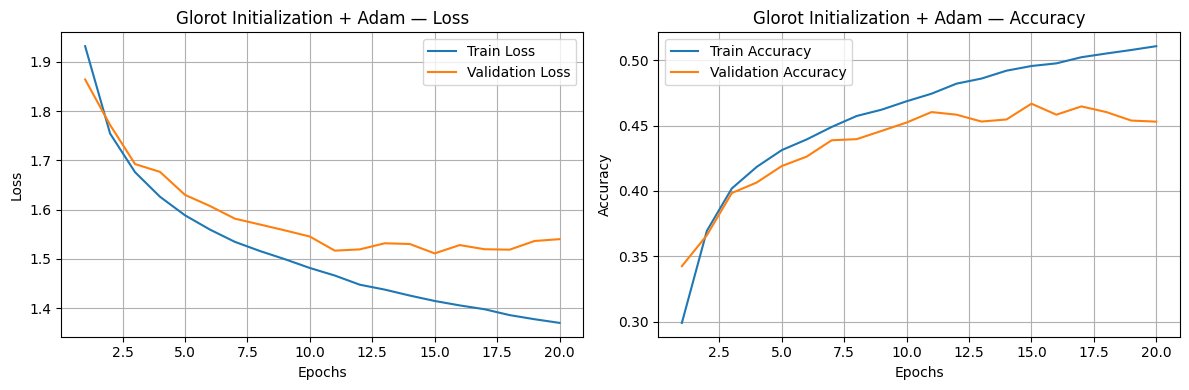

In [17]:
plot_loss_accuracy(history_glorot, "Glorot Initialization + Adam")

In [18]:
# Using the best initialization, compare SGD vs Adam
from tensorflow.keras.optimizers import SGD

# Model with best init + SGD
model_sgd = build_mlp(best_init)

model_sgd.compile(loss = "sparse_categorical_crossentropy",
                  optimizer = SGD(learning_rate=0.001, momentum=0.0),
                  metrics = ["accuracy"]
                 )

history_sgd = model_sgd.fit(X_train, y_train,
                            epochs=EPOCHS,
                            batch_size=BATCH_SIZE,
                            validation_data=(X_valid, y_valid),
                            verbose=1
                           )

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 964us/step - accuracy: 0.1692 - loss: 2.2551 - val_accuracy: 0.2800 - val_loss: 2.0399
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 866us/step - accuracy: 0.2875 - loss: 2.0105 - val_accuracy: 0.3192 - val_loss: 1.9317
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.3212 - loss: 1.9203 - val_accuracy: 0.3388 - val_loss: 1.8770
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - accuracy: 0.3407 - loss: 1.8717 - val_accuracy: 0.3543 - val_loss: 1.8423
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 872us/step - accuracy: 0.3548 - loss: 1.8384 - val_accuracy: 0.3623 - val_loss: 1.8164
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 859us/step - accuracy: 0.3656 - loss: 1.8124 - val_accuracy: 0.3699 - val_loss: 1.7950
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 862us/step - accuracy: 0.3730 - loss: 1.7906 - val_accuracy: 0.3761 - val_loss: 1.7771
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 1s 858us/step - accuracy: 0.3822 -

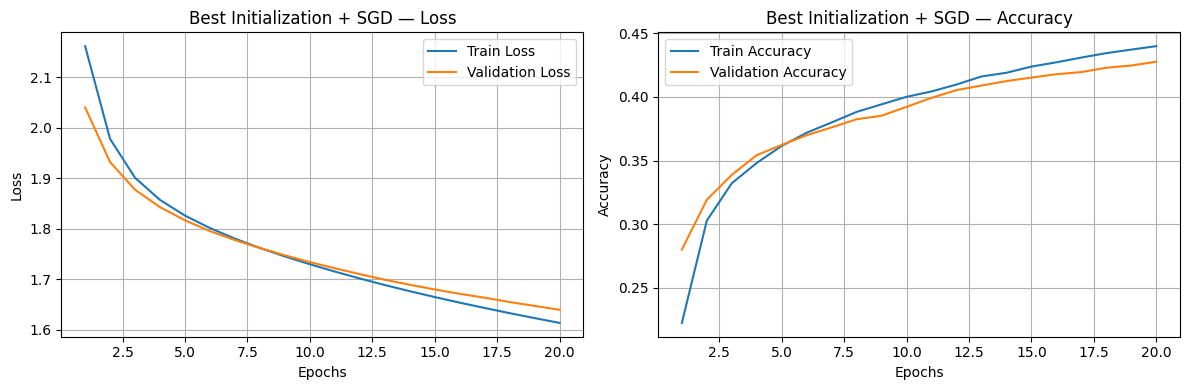

In [19]:
plot_loss_accuracy(history_sgd, "Best Initialization + SGD")

In [20]:
# Model with best init + Adam
model_adam = build_mlp(best_init)

model_adam.compile(loss = "sparse_categorical_crossentropy",
                   optimizer = Adam(learning_rate=1e-2),
                   metrics = ["accuracy"]
                  )

history_adam = model_adam.fit(X_train, y_train,
                              epochs=EPOCHS,
                              batch_size=BATCH_SIZE,
                              validation_data=(X_valid, y_valid),
                              verbose=1
                             )

val_acc_sgd = history_sgd.history["val_accuracy"][-1]
val_acc_adam = history_adam.history["val_accuracy"][-1]

print(f"Best init ({best_init}) + SGD  -> final val accuracy: {val_acc_sgd:.4f}")
print(f"Best init ({best_init}) + Adam -> final val accuracy: {val_acc_adam:.4f}")

Epoch 1/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1074 - loss: 2.6677 - val_accuracy: 0.1002 - val_loss: 2.3057
Epoch 2/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1002 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 3/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1006 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 4/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1007 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 5/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1007 - loss: 2.3040 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 6/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1007 - loss: 2.3041 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 7/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1007 - loss: 2.3041 - val_accuracy: 0.1002 - val_loss: 2.3059
Epoch 8/20
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.1007 - loss: 2.3041 - 

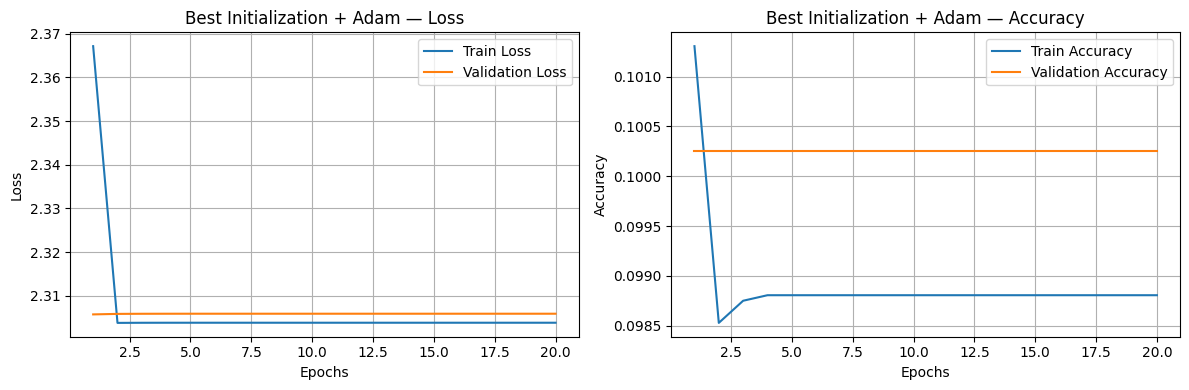

In [21]:
plot_loss_accuracy(history_adam, "Best Initialization + Adam")

<b>Comment:</b> Too large learning rate.

### Question 2

In [22]:
from tensorflow.keras.layers import BatchNormalization, Dropout, Activation

best_optimizer = Adam(learning_rate=1e-3)

model_bn_do = Sequential([Input(shape=(32, 32, 3)),
                          Flatten(),
                          Dense(100, kernel_initializer=best_init),
                          BatchNormalization(),
                          Activation("relu"),
                          Dropout(0.3),
                          Dense(50, kernel_initializer=best_init),
                          BatchNormalization(),
                          Activation("relu"),
                          Dense(10, activation="softmax")]
                        )

model_bn_do.compile(loss = "sparse_categorical_crossentropy",
                    optimizer = best_optimizer,
                    metrics = ["accuracy"]
                   )

model_bn_do.summary()

history_bn_do = model_bn_do.fit(X_train, y_train,
                                epochs=20,
                                batch_size=64,
                                validation_data=(X_valid, y_valid)
                               )

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,460 (1.20 MB)

 Trainable params: 313,160 (1.19 MB)

 Non-trainable params: 300 (1.17 KB)

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2934 - loss: 2.0118 - val_accuracy: 0.3407 - val_loss: 1.7918
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4034 - loss: 1.6816 - val_accuracy: 0.3300 - val_loss: 1.8268
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4312 - loss: 1.5967 - val_accuracy: 0.3787 - val_loss: 1.7264
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4510 - loss: 1.5326 - val_accuracy: 0.3928 - val_loss: 1.6606
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4660 - loss: 1.4952 - val_accuracy: 0.4104 - val_loss: 1.6514
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4764 - loss: 1.4611 - val_accuracy: 0.3954 - val_loss: 1.6850
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4901 - loss: 1.4298 - val_accuracy: 0.4369 - val_loss: 1.5863
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4972 - loss: 1.4102 - val_accuracy: 0.

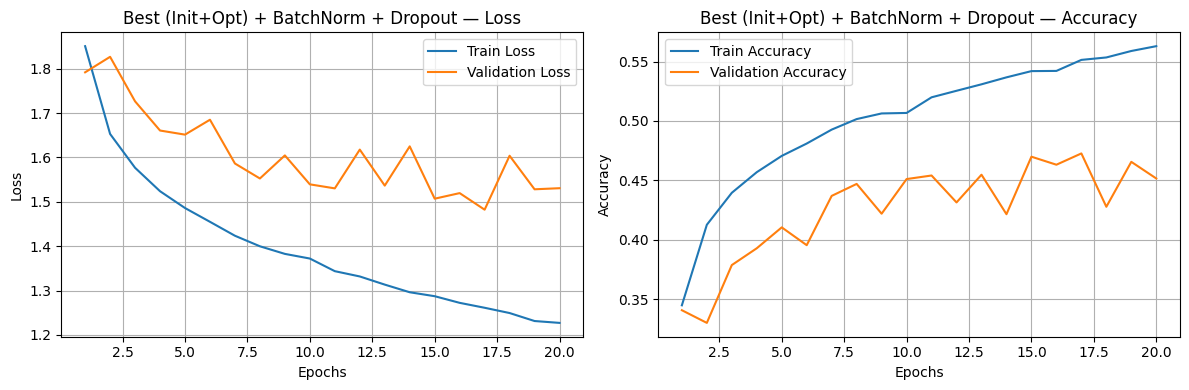

In [23]:
plot_loss_accuracy(history_bn_do, "Best (Init+Opt) + BatchNorm + Dropout")

### Question 3

In [24]:
# set the seed numbers for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

best_optimizer = Adam(learning_rate=1e-3)

# Learning rate scheduler: step decay
def lr_schedule(epoch, lr):
    if epoch%10 == 0:
        return lr * 0.1
    else:
        return lr

lr_callback = tf.keras.callbacks.LearningRateScheduler(lr_schedule)

# Build the SAME model as Bullet 2 (BN + Dropout)
model_bn_do_lr = Sequential([Input(shape=(32, 32, 3)),
                             Flatten(),
                             Dense(100, kernel_initializer=best_init),
                             BatchNormalization(),
                             Activation("relu"),
                             Dropout(0.3),
                             Dense(50, kernel_initializer=best_init),
                             BatchNormalization(),
                             Activation("relu"),
                             Dense(10, activation="softmax")]
                           )

model_bn_do_lr.compile(loss = "sparse_categorical_crossentropy",
                       optimizer = best_optimizer, # Use the new optimizer instance
                       metrics = ["accuracy"]
                      )

model_bn_do_lr.summary()

# Train with LR scheduling
history_bn_do_lr = model_bn_do_lr.fit(X_train, y_train,
                                      epochs=20,
                                      batch_size=64,
                                      validation_data=(X_valid, y_valid),
                                      callbacks=[lr_callback]
                                     )

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 313,460 (1.20 MB)

 Trainable params: 313,160 (1.19 MB)

 Non-trainable params: 300 (1.17 KB)

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2264 - loss: 2.1557 - val_accuracy: 0.3663 - val_loss: 1.8226 - learning_rate: 1.0000e-04
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3657 - loss: 1.8076 - val_accuracy: 0.3851 - val_loss: 1.7476 - learning_rate: 1.0000e-04
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3934 - loss: 1.7239 - val_accuracy: 0.4103 - val_loss: 1.6835 - learning_rate: 1.0000e-04
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4187 - loss: 1.6700 - val_accuracy: 0.4220 - val_loss: 1.6622 - learning_rate: 1.0000e-04
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4288 - loss: 1.6308 - val_accuracy: 0.4172 - val_loss: 1.6394 - learning_rate: 1.0000e-04
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4362 - loss: 1.5977 - val_accuracy: 0.4221 - val_loss: 1.6292 - learning_rate: 1.0000e-04
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 

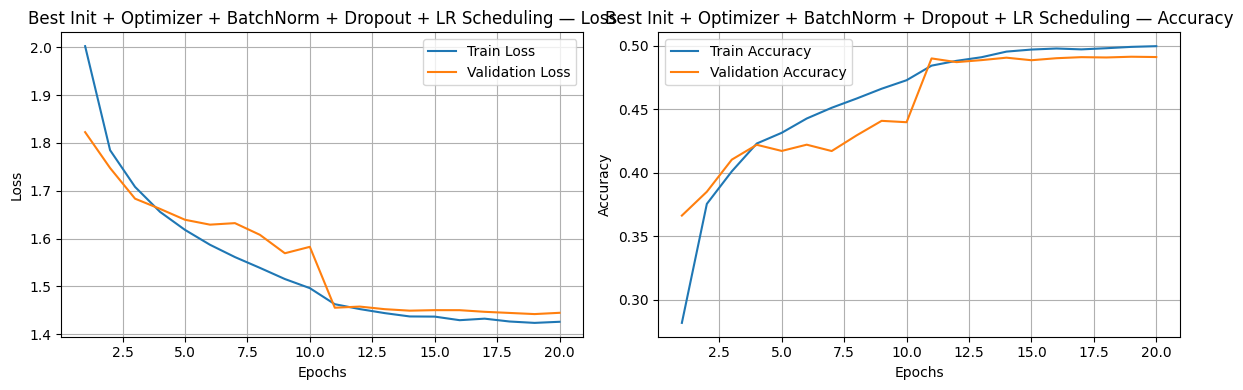

In [25]:
plot_loss_accuracy(history_bn_do_lr, "Best Init + Optimizer + BatchNorm + Dropout + LR Scheduling")

### Question 4

The choice of initialization and optimizer affected accuracy and performance of the model in terms of validation. SGD outperformed ADAM for the choice of parameters. The Batch Normalization and Dropout led to substantial overfitting of the model, but the use of LR scheduling rectified the issue and lead to a model that does not overfit and perform better than all other choices.